<div style = "font-family:'Segoe UI'; font-size: 25px; text-align: center; color: #172774; font-weight: bold; padding: 10px auto">
    🛳 TITANIC DISASTER SURVIVOR PREDICTION 🛳
</div>

<img src = "https://thumbor.forbes.com/thumbor/960x0/https%3A%2F%2Fspecials-images.forbesimg.com%2Fdam%2Fimageserve%2F877330410%2F960x0.jpg%3Ffit%3Dscale" >

<div style = "font-family:'Segoe UI'; border-left: 5px solid red; padding: 5px 0px 10px 10px; border-radius: 5px">
    <h2>Importing the required packages</h2>
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

<div style = "font-family:'Segoe UI'; border-left: 5px solid red; padding: 5px 0px 10px 10px; border-radius: 5px">
    <h2>Importing the data</h2>
</div>

In [2]:
train_df = pd.read_csv("../input/titanic/train.csv")
test_df = pd.read_csv("../input/titanic/test.csv")

In [3]:
train = train_df.copy()
test = test_df.copy()

In [4]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<div style = "font-family:'Segoe UI'; border-left: 5px solid red; padding: 5px 0px 10px 10px; border-radius: 5px">
    <h2>Removing the columns with unique values</h2>
</div>

In [5]:
cols_to_be_removed = ["PassengerId", "Name", "Ticket"]

In [6]:
train.drop(cols_to_be_removed, axis=1, inplace=True)
test.drop(cols_to_be_removed, axis=1, inplace=True)

In [7]:
print(train.shape)

(891, 9)


In [8]:
train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


In [9]:
test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,3,male,34.5,0,0,7.8292,NaN,Q
1,3,female,47.0,1,0,7.0000,NaN,S
2,2,male,62.0,0,0,9.6875,NaN,Q
3,3,male,27.0,0,0,8.6625,NaN,S
4,3,female,22.0,1,1,12.2875,NaN,S


<div style = "font-family:'Segoe UI'; border-left: 5px solid red; padding: 5px 0px 10px 10px; border-radius: 5px">
    <h2>Checking and cleaning null values in train and test data</h2>
</div>

<div style = "font-family:'Segoe UI';">Data cleaning in Train Data</div>

In [10]:
print(train.isna().sum())

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Cabin       687
Embarked      2
dtype: int64


In [11]:
print(train["Age"].mean())
print(train["Embarked"].mode())

29.69911764705882
0    S
dtype: object


In [12]:
train["Age"].fillna(train["Age"].mean(), inplace=True)

In [13]:
train.drop(["Cabin"],axis=1, inplace=True)

In [14]:
train.dropna(inplace=True) #Remaining 2 values in Embarked columns

In [15]:
print(train.shape)

(889, 8)


In [16]:
print(train.isna().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


<div style = "font-family:'Segoe UI';">Data cleaning in Test Data</div>

In [17]:
print(test.shape)

(418, 8)


In [18]:
print(test.isna().sum())

Pclass        0
Sex           0
Age          86
SibSp         0
Parch         0
Fare          1
Cabin       327
Embarked      0
dtype: int64


In [19]:
print(test["Age"].mean())
print(test["Fare"].mean())

30.272590361445783
35.6271884892086


In [20]:
test["Age"].fillna(test["Age"].mean(), inplace=True)

In [21]:
test.drop(["Cabin"],axis=1,inplace=True)

In [22]:
test["Fare"].fillna(test["Fare"].mean(), inplace=True)

In [23]:
print(test.isna().sum())

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


<img src = "https://image.freepik.com/free-vector/happy-family-cleaning-apartment_74855-6501.jpg" >

<div style = "font-family:'Segoe UI';">All null values are handled in train and test data ✅ </div>

In [24]:
train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [25]:
test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,34.5,0,0,7.8292,Q
1,3,female,47.0,1,0,7.0000,S
2,2,male,62.0,0,0,9.6875,Q
3,3,male,27.0,0,0,8.6625,S
4,3,female,22.0,1,1,12.2875,S


<div style = "font-family:'Segoe UI'; border-left: 5px solid red; padding: 5px 0px 10px 10px; border-radius: 5px">
    <h2>Vizualizing the data</h2>
</div>

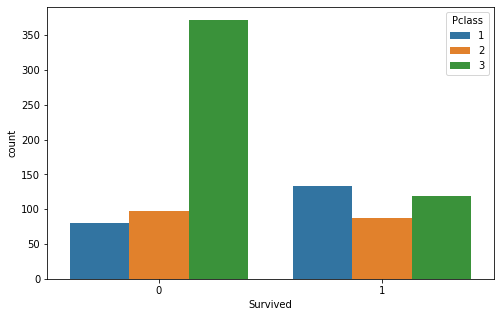

In [26]:
plt.figure(figsize=(8,5))
sns.countplot(x='Survived', hue='Pclass', data= train)
plt.show()

<div style = "font-family:'Segoe UI';"> ➡️ We can see that there are more people from third class who fail to survive, while the survival ratio is more or less similar in all classes </div>

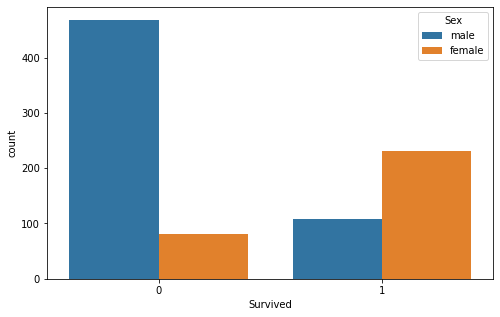

In [27]:
plt.figure(figsize=(8,5))
sns.countplot(x='Survived', hue='Sex', data= train)
plt.show()

<div style = "font-family:'Segoe UI';"> ➡️ We can see that there are more female survivors compared to male </div>

<div style = "font-family:'Segoe UI'; border-left: 5px solid red; padding: 5px 0px 10px 10px; border-radius: 5px">
    <h2>Encoding the categorical values in the data</h2>
</div>

In [28]:
import category_encoders as ce

In [29]:
encoder= ce.OrdinalEncoder(cols=['Sex'],return_df=True, mapping=[{'col':'Sex','mapping':{'male':0,'female':1}}])

In [30]:
train = encoder.fit_transform(train)
test = encoder.fit_transform(test)

In [31]:
from sklearn.preprocessing import OneHotEncoder

In [32]:
encoder = ce.OneHotEncoder(cols='Embarked',handle_unknown='return_nan',return_df=True,use_cat_names=True)

In [33]:
train = encoder.fit_transform(train)
test = encoder.fit_transform(test)

In [34]:
train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_S,Embarked_C,Embarked_Q
0,0,3,0,22.0,1,0,7.2500,1.0,0.0,0.0
1,1,1,1,38.0,1,0,71.2833,0.0,1.0,0.0
2,1,3,1,26.0,0,0,7.9250,1.0,0.0,0.0
3,1,1,1,35.0,1,0,53.1000,1.0,0.0,0.0
4,0,3,0,35.0,0,0,8.0500,1.0,0.0,0.0


In [35]:
test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Embarked_C
0,3,0,34.5,0,0,7.8292,1.0,0.0,0.0
1,3,1,47.0,1,0,7.0000,0.0,1.0,0.0
2,2,0,62.0,0,0,9.6875,1.0,0.0,0.0
3,3,0,27.0,0,0,8.6625,0.0,1.0,0.0
4,3,1,22.0,1,1,12.2875,0.0,1.0,0.0


<div style = "font-family:'Segoe UI';">All categorical values are encoded in the data ✅ </div>

<div style = "font-family:'Segoe UI'; border-left: 5px solid red; padding: 5px 0px 10px 10px; border-radius: 5px">
    <h2>Splitting the dependent and independent variables</h2>
</div>

In [36]:
X = train.iloc[:,1:].values
y = train.iloc[:,0].values

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2)

<div style = "font-family:'Segoe UI'; border-left: 5px solid red; padding: 5px 0px 10px 10px; border-radius: 5px">
    <h2>Scaling the values in data to reduce spread</h2>
</div>

In [39]:
from sklearn.preprocessing import StandardScaler

In [40]:
sc = StandardScaler()

In [41]:
train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_S,Embarked_C,Embarked_Q
0,0,3,0,22.0,1,0,7.2500,1.0,0.0,0.0
1,1,1,1,38.0,1,0,71.2833,0.0,1.0,0.0
2,1,3,1,26.0,0,0,7.9250,1.0,0.0,0.0
3,1,1,1,35.0,1,0,53.1000,1.0,0.0,0.0
4,0,3,0,35.0,0,0,8.0500,1.0,0.0,0.0


In [42]:
print(train["Fare"].var())
print(train["Age"].var())

2469.8419353092113
168.17852473095093


In [43]:
X_train[:,5:6] = sc.fit_transform(X_train[:,5:6])
X_test[:,5:6] = sc.transform(X_test[:,5:6])

In [44]:
X_train[:,2:3] = sc.fit_transform(X_train[:,2:3])
X_test[:,2:3] = sc.transform(X_test[:,2:3])

<div style = "font-family:'Segoe UI'; border-left: 5px solid red; padding: 5px 0px 10px 10px; border-radius: 5px">
    <h2>Gradient Boosting Classifier</h2>
</div>

<div style = "font-family:'Segoe UI';">
Gradient Boosting is an Ensemble Learning method. <br>
In Gradient Boosting, each predictor tries to improve on its predecessor by reducing the errors. But the fascinating idea behind Gradient Boosting is that instead of fitting a predictor on the data at each iteration, it actually fits a new predictor to the residual errors made by the previous predictor.
</div>

In [45]:
from sklearn.ensemble import GradientBoostingClassifier

In [46]:
gbc = GradientBoostingClassifier()

In [47]:
gbc.fit(X_train, y_train)

GradientBoostingClassifier()

In [48]:
y_pred = gbc.predict(X_test)

<div style = "font-family:'Segoe UI'; border-left: 5px solid red; padding: 5px 0px 10px 10px; border-radius: 5px">
    <h2>Validating the model</h2>
</div>

In [49]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [50]:
print(accuracy_score(y_test,y_pred))

0.8314606741573034


<div style = "font-family:'Segoe UI';">The model is 83.15 % accurate 😀😀 </div>

In [51]:
print(confusion_matrix(y_test,y_pred))

[[103   9]
 [ 21  45]]


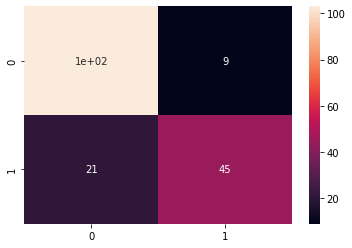

In [52]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True)
plt.show()

<div style = "font-family:'Segoe UI'; border-left: 5px solid red; padding: 5px 0px 10px 10px; border-radius: 5px">
    <h2>Predicting the survival status for the given test data</h2>
</div>

In [53]:
test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Embarked_C
0,3,0,34.5,0,0,7.8292,1.0,0.0,0.0
1,3,1,47.0,1,0,7.0000,0.0,1.0,0.0
2,2,0,62.0,0,0,9.6875,1.0,0.0,0.0
3,3,0,27.0,0,0,8.6625,0.0,1.0,0.0
4,3,1,22.0,1,1,12.2875,0.0,1.0,0.0


In [54]:
test_data = test.values

In [55]:
test_data[:,5:6] = sc.fit_transform(test_data[:,5:6])
test_data[:,2:3] = sc.fit_transform(test_data[:,2:3])

In [56]:
prediction = gbc.predict(test_data)

<div style = "font-family:'Segoe UI';"> Saving the results into a csv file ✅ </div>

In [57]:
submission= pd.DataFrame({'PassengerId' : test_df['PassengerId'], 'Survived': prediction })
submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [58]:
filename= 'gender_submission.csv'
submission.to_csv(filename, index=False)

<div style = "font-family:'Segoe UI';"> If you liked the notebook, and found it useful, please <strong>upvote</strong> and <strong>share</strong> it to your friends! 😀😀 </div>